# Prelaboratorio: spaCy en acción sobre una noticia

**Duración estimada:** 25 minutos

## Propósito
Este notebook funciona como puente entre los materiales introductorios y el laboratorio integrador. Vas a repasar el pipeline completo de `spaCy` sobre una noticia breve y a practicar una lectura crítica de los resultados.

## Prerrequisitos
- Haber recorrido `000_intro_pln_y_spacy.ipynb`, `001_spacy_fundamentos.ipynb` y `002_spacy_pipeline_y_apoyo.ipynb`.
- Manejar listas, diccionarios y comprensiones básicas en Python.


## Modalidad sugerida: trabajo con IA como copiloto cognitivo

En esta materia la IA forma parte del dispositivo pedagógico. Podés usar un asistente de IA para:
- anticipar qué entidades o verbos podrían aparecer;
- proponer una estrategia de análisis;
- explicarte una salida que no entendiste;
- auditar una interpretación que te parezca dudosa.

**Importante:** la IA procesa patrones, pero no decide por vos. La lectura final de los resultados tiene que ser humana, situada y justificada.


In [1]:
!pip install spacy pandas matplotlib wordcloud -q
!python -m spacy download es_core_news_lg -q



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import spacy
import pandas as pd
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from spacy import displacy

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_colwidth', None)

nlp = spacy.load("es_core_news_sm")
print("Entorno configurado correctamente.")


Entorno configurado correctamente.


## 1. Repaso rápido: qué herramientas ya conoces

Antes de mirar la noticia, recuperá estas ideas:
- tokenización: cómo se segmenta el texto;
- lematización: cómo se lleva cada palabra a una forma base;
- POS: cómo se etiqueta la función gramatical;
- NER: cómo se detectan entidades del mundo real;
- dependencias: cómo se vinculan las palabras entre sí.


## 2. Demostración: un pipeline completo con spaCy

Vamos a trabajar con un texto breve de estilo periodístico. Antes de ejecutarlo, podés pedirle a un asistente de IA que anticipe:
- qué personas y organizaciones cree que van a aparecer;
- qué verbos podrían ser centrales;
- qué errores posibles podría cometer el modelo.


In [4]:
print("Cargando modelo de spaCy para español...")
print(f"Componentes del pipeline: {nlp.pipe_names}\n")

texto_noticia = (
    "El presidente Javier Milei anunció ayer en Casa Rosada un nuevo plan de inversiones por "
    "500 millones de dólares. Microsoft Argentina y Mercado Libre serán las primeras empresas "
    "en participar. María González, ministra de Tecnología, destacó que el proyecto generará "
    "3.000 empleos en Buenos Aires y Córdoba durante 2025."
)

print("--- Texto a analizar ---")
print(texto_noticia)

doc = nlp(texto_noticia)
print(f"\nTexto procesado: se encontraron {len(doc)} tokens.")


Cargando modelo de spaCy para español...
Componentes del pipeline: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

--- Texto a analizar ---
El presidente Javier Milei anunció ayer en Casa Rosada un nuevo plan de inversiones por 500 millones de dólares. Microsoft Argentina y Mercado Libre serán las primeras empresas en participar. María González, ministra de Tecnología, destacó que el proyecto generará 3.000 empleos en Buenos Aires y Córdoba durante 2025.

Texto procesado: se encontraron 54 tokens.


### 2.1 Tokenización detallada

En esta salida conviene observar no solo el token, sino también el lema, la categoría gramatical y si el modelo lo considera una stopword.


In [5]:
print("--- Análisis de los primeros 12 tokens ---")
print(f"{'Token':<18} {'Lema':<18} {'POS':<10} {'Stopword?':<12} {'Puntuación?'}")
print("-" * 75)

for token in doc[:12]:
    print(
        f"{token.text:<18} {token.lemma_:<18} {token.pos_:<10} "
        f"{'Si' if token.is_stop else 'No':<12} {'Si' if token.is_punct else 'No'}"
    )


--- Análisis de los primeros 12 tokens ---
Token              Lema               POS        Stopword?    Puntuación?
---------------------------------------------------------------------------
El                 el                 DET        Si           No
presidente         presidente         NOUN       No           No
Javier             Javier             PROPN      No           No
Milei              Milei              PROPN      No           No
anunció            anunciar           VERB       No           No
ayer               ayer               ADV        No           No
en                 en                 ADP        Si           No
Casa               Casa               PROPN      No           No
Rosada             Rosada             PROPN      No           No
un                 uno                DET        Si           No
nuevo              nuevo              ADJ        Si           No
plan               plan               NOUN       No           No


### 2.2 Reconocimiento de entidades nombradas

El valor pedagógico de esta parte no está solo en detectar entidades, sino también en discutirlas. Si alguna clasificación te resulta extraña, no la tomes como un fracaso del ejercicio: tomala como una oportunidad de análisis.


In [6]:
entidades_data = []
for ent in doc.ents:
    entidades_data.append({
        'Texto': ent.text,
        'Tipo': ent.label_,
        'Explicación': spacy.explain(ent.label_),
    })

df_entidades = pd.DataFrame(entidades_data)

print("--- Entidades nombradas detectadas ---")
if not df_entidades.empty:
    print(df_entidades.to_string(index=False))
else:
    print("No se encontraron entidades en el texto.")


--- Entidades nombradas detectadas ---
              Texto Tipo                                                                  Explicación
       Javier Milei  PER                                                      Named person or family.
        Casa Rosada  LOC                          Non-GPE locations, mountain ranges, bodies of water
Microsoft Argentina MISC Miscellaneous entities, e.g. events, nationalities, products or works of art
      Mercado Libre  LOC                          Non-GPE locations, mountain ranges, bodies of water
     María González  PER                                                      Named person or family.
         Tecnología  PER                                                      Named person or family.
       Buenos Aires  LOC                          Non-GPE locations, mountain ranges, bodies of water
            Córdoba  LOC                          Non-GPE locations, mountain ranges, bodies of water


In [6]:
displacy.render(doc, style='ent', jupyter=True)


**Pausa crítica**

Elegí una entidad de la tabla y respondé:
- La clasificación te parece adecuada?
- Qué evidencia del texto la sostiene?
- Qué podría haber confundido al modelo?


### 2.3 Acciones y estructura sintáctica

Ahora vamos a mirar verbos y dependencias para entender mejor qué acciones aparecen y cómo se organiza la primera oración.


In [ ]:
verbos = [token.lemma_.lower() for token in doc if token.pos_ == "VERB" and not token.is_stop]
verbos_freq = Counter(verbos)

print("--- Verbos principales ---")
if verbos:
    print(verbos_freq.most_common(5))
else:
    print("No se encontraron verbos relevantes.")

primera_oracion = list(doc.sents)[0]
print("\n--- Primera oración ---")
print(primera_oracion)


In [ ]:
displacy.render(primera_oracion, style='dep', jupyter=True, options={'distance': 120, 'compact': True})


## 3. Extracción de palabras clave

En esta parte vamos a sintetizar el texto mediante palabras clave. La idea no es reemplazar la lectura humana, sino construir una primera capa de interpretación.


In [7]:
palabras_clave = [
    token.lemma_.lower()
    for token in doc
    if token.is_alpha and not token.is_stop and len(token.text) > 2 and token.pos_ in ['NOUN', 'VERB', 'PROPN']
]

frecuencia_palabras = Counter(palabras_clave)

print("--- Top 5 palabras clave ---")
for palabra, freq in frecuencia_palabras.most_common(5):
    print(f"- {palabra}: {freq}")


--- Top 5 palabras clave ---
- presidente: 1
- javier: 1
- milei: 1
- anunciar: 1
- casa: 1


### 3.1 Visualización rápida

La nube de palabras te ofrece una vista panorámica. Mirala como apoyo, no como conclusión final.


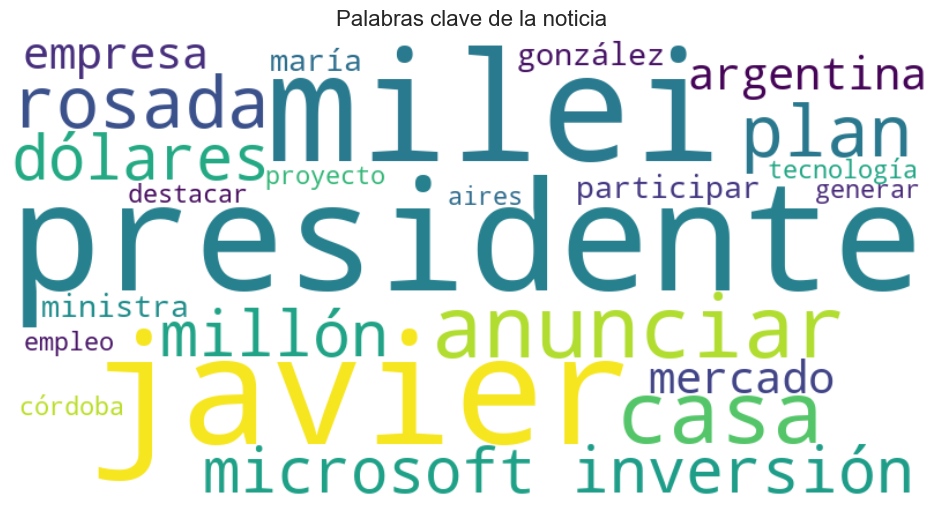

In [8]:
if frecuencia_palabras:
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=50,
    ).generate_from_frequencies(frecuencia_palabras)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title('Palabras clave de la noticia', fontsize=16)
    ax.axis('off')
    plt.show()
else:
    print("No hay suficientes palabras para generar la nube.")


## 4. Adelanto del laboratorio integrador

En el próximo notebook vas a construir un analizador de noticias más completo. La diferencia es que ya no vas a trabajar con un ejemplo resuelto, sino con un laboratorio con huecos para completar.

**Modalidad de trabajo del laboratorio:** pair programming con IA.

En esta cátedra, eso significa que la díada de trabajo está formada por vos y un asistente de IA. La IA puede proponer, explicar, depurar y contrastar, pero no reemplaza tu criterio ni tu responsabilidad sobre el resultado.


## 5. Antes de pasar al laboratorio

Comprobá si podés hacer estas tres cosas:
1. explicar qué información nueva agrega `spaCy` a un texto;
2. identificar una salida discutible del modelo y justificar por qué;
3. usar un asistente de IA para formular una hipótesis y después contrastarla con la salida real.

**Microbitácora sugerida**
- Qué le pediste a la IA?
- Qué parte de la respuesta te resultó útil?
- Qué corregiste o descartaste?
- Qué aprendiste al comparar la predicción con la ejecución del notebook?
